In [27]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ks_2samp

In [34]:
idxs = np.arange(0, 20)

types = {
    "No TI": "noTI_0.1",
    "0 Hz TI": "1000_0_0.32_0.1",
    "5 Hz TI": "1000_5_0.9_0.1",
    "130 Hz TI": "1000_130_0.9_0.1"
}

project = "temporal-interference-1"

In [35]:
weights = {}

for (type, filename) in types.items():
    final_weights = []
    
    for idx in idxs:
        final_weights.append(pd.read_csv(f"../output/{project}/{idx}/in-vivo/{filename}/final_synapse_weights.csv"))
    
    final_weights = pd.concat(final_weights, ignore_index = True)
    
    weights[type] = final_weights

## Distribution of the final weights

In [36]:
colors = {
    "No TI": "tab:blue",
    "0 Hz TI": "tab:red",
    "5 Hz TI": "tab:orange",
    "130 Hz TI": "tab:green"
}

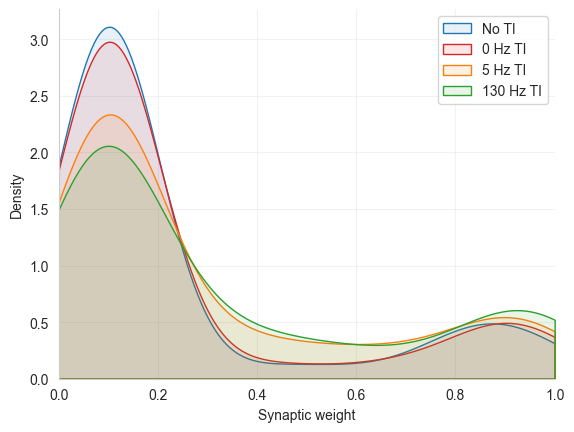

In [37]:
fig, ax = plt.subplots(nrows = 1, ncols = 1)

for condition in weights.keys():
    sns.kdeplot(
        weights[condition].Weight,
        bw_adjust = 1,
        ax = ax,
        clip = (0, 1),
        label = condition,
        fill = True,
        alpha = 0.1,
        color = colors[condition]
    )

ax.set_xlim(0, 1)
ax.set_xlabel("Synaptic weight")

ax.grid(alpha = 0.25)
sns.despine(top = True, right = True)

plt.legend()
plt.show()

In [55]:
print("No TI vs 5 Hz")
print(ks_2samp(weights["No TI"].Weight.to_numpy(), weights["5 Hz TI"].Weight.to_numpy()))

print("No TI vs 130 Hz")
print(ks_2samp(weights["No TI"].Weight.to_numpy(), weights["130 Hz TI"].Weight.to_numpy()))

print("No TI vs 0 Hz")
print(ks_2samp(weights["No TI"].Weight.to_numpy(), weights["0 Hz TI"].Weight.to_numpy()))

print("5 Hz vs 130 Hz")
print(ks_2samp(weights["5 Hz TI"].Weight.to_numpy(), weights["130 Hz TI"].Weight.to_numpy()))

No TI vs 5 Hz
KstestResult(statistic=0.235, pvalue=2.9607827368482373e-05, statistic_location=0.1, statistic_sign=1)
No TI vs 130 Hz
KstestResult(statistic=0.295, pvalue=4.448673570292354e-08, statistic_location=0.1, statistic_sign=1)
No TI vs 0 Hz
KstestResult(statistic=0.035, pvalue=0.9997218397355462, statistic_location=0.8372085664444248, statistic_sign=1)
5 Hz vs 130 Hz
KstestResult(statistic=0.07, pvalue=0.7125821300149116, statistic_location=0.1000000000000114, statistic_sign=1)
